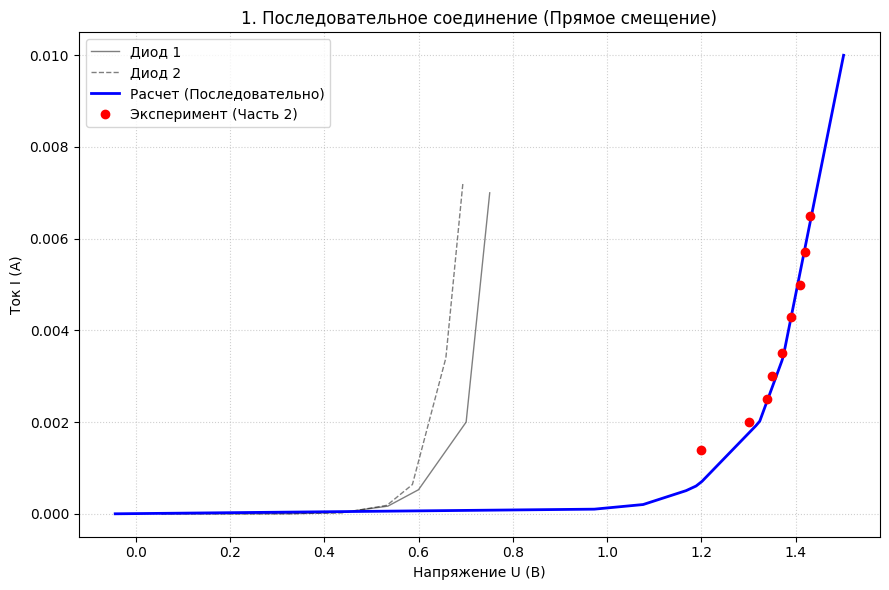

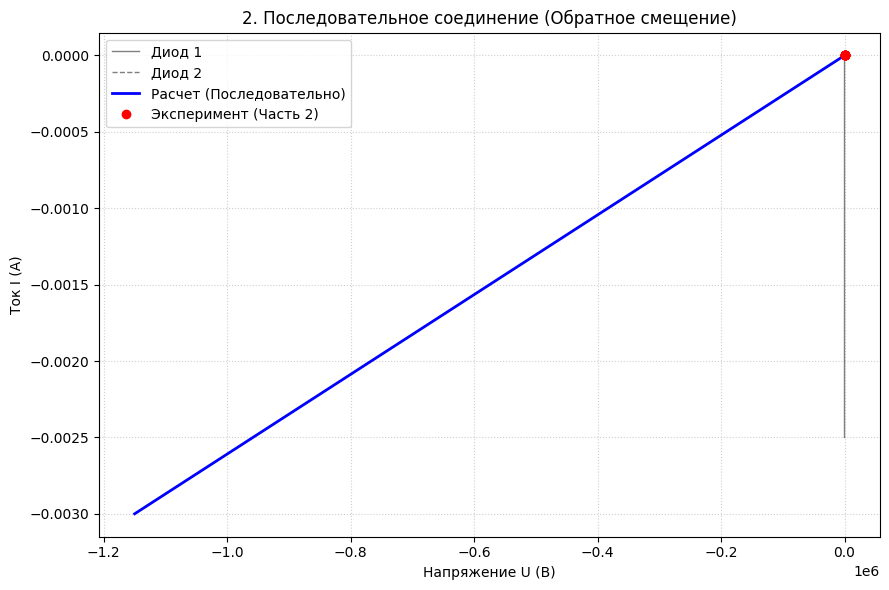

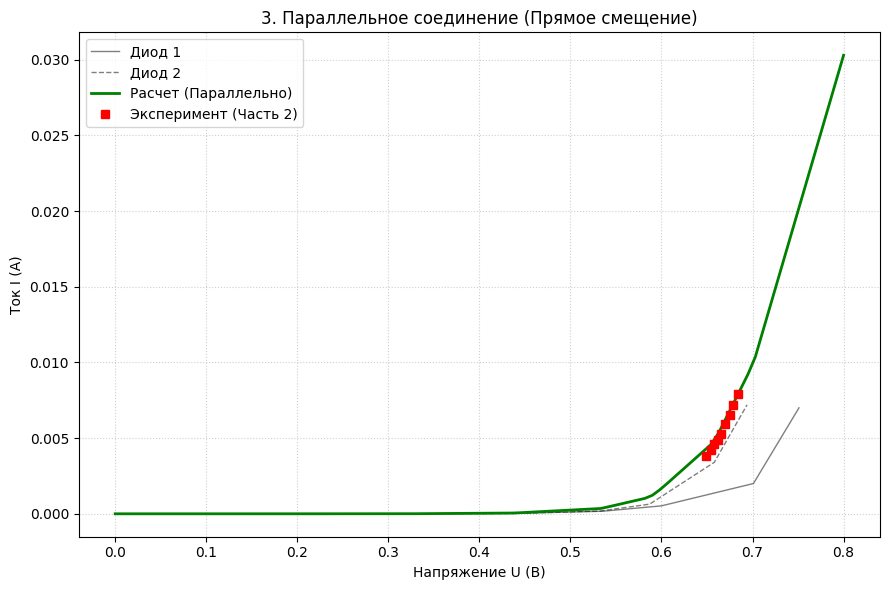

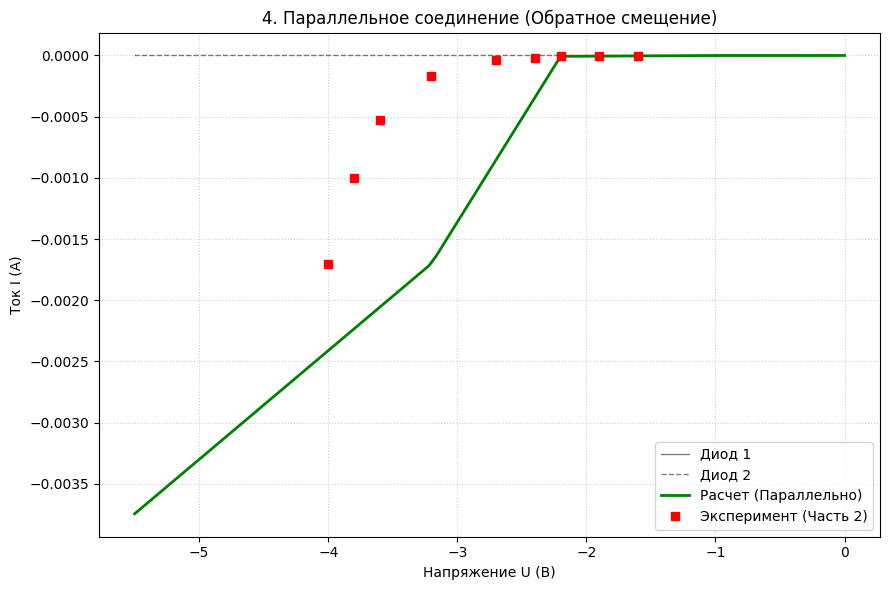

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# ==========================================
# 1. ДАННЫЕ ИЗ ЧАСТИ 1 (Исходные диоды)
# ==========================================

# Диод 1 (Стабилитрон)
d1_U = np.array([-4.1, -3.2, -2.2, -1.0, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.438, 0.535, 0.600, 0.701, 0.751])
d1_I = np.array([-2.5e-3, -1.7e-3, -7e-6, -260e-9, -48e-9, -24e-9, -17e-9, -12e-9, -9e-9, 
                 24e-9, 87e-9, 638e-9, 4e-6, 31e-6, 167e-6, 525e-6, 2e-3, 7e-3])

# Диод 2 (Выпрямительный)
d2_U = np.array([-5.5, -3.2, -2.2, -1.1, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.439, 0.533, 0.587, 0.658, 0.694])
d2_I = np.array([-7e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, 
                 2e-9, 11e-9, 119e-9, 1.8e-6, 21e-6, 185e-6, 638e-6, 3.4e-3, 7.2e-3])


# ==========================================
# 2. ДАННЫЕ ИЗ ЧАСТИ 2 (Эксперимент для проверки)
# ==========================================

# --- Последовательное соединение ---
# Прямое
exp_ser_fwd_U = np.array([1.2, 1.3, 1.34, 1.35, 1.37, 1.39, 1.41, 1.42, 1.43])
exp_ser_fwd_I = np.array([1.4e-3, 2.0e-3, 2.5e-3, 3.0e-3, 3.5e-3, 4.3e-3, 5.0e-3, 5.7e-3, 6.5e-3])
# Обратное
exp_ser_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.3, -3.8, -4.4, -4.9])
exp_ser_rev_I = np.array([-1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9])

# --- Параллельное соединение ---
# Прямое (U переведены в Вольты)
exp_par_fwd_U = np.array([0.649, 0.654, 0.658, 0.662, 0.665, 0.670, 0.675, 0.679, 0.684])
exp_par_fwd_I = np.array([3.8e-3, 4.2e-3, 4.6e-3, 4.9e-3, 5.3e-3, 5.9e-3, 6.5e-3, 7.2e-3, 7.9e-3])
# Обратное
exp_par_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.2, -3.6, -3.8, -4.0])
exp_par_rev_I = np.array([-1.3e-6, -3.2e-6, -7.4e-6, -17e-6, -38e-6, -170e-6, -528e-6, -1e-3, -1.7e-3])


# ==========================================
# 3. РАСЧЕТ ГРАФИЧЕСКИМ МЕТОДОМ
# ==========================================

def calc_graphic_series(I_range):
    """Сложение последовательно: При одинаковом Токе I суммируем Напряжения U"""
    # Интерполируем U как функцию от I
    f1 = interpolate.interp1d(d1_I, d1_U, kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_I, d2_U, kind='linear', fill_value="extrapolate")
    
    U_total = f1(I_range) + f2(I_range)
    return U_total, I_range

def calc_graphic_parallel(U_range):
    """Сложение параллельно: При одинаковом Напряжении U суммируем Токи I"""
    # Интерполируем I как функцию от U
    f1 = interpolate.interp1d(d1_U, d1_I, kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_U, d2_I, kind='linear', fill_value="extrapolate")
    
    I_total = f1(U_range) + f2(U_range)
    return U_range, I_total


# ==========================================
# 4. ПОСТРОЕНИЕ ГРАФИКОВ
# ==========================================

plt.style.use('default') # Чистый стиль

# --- 1. ПОСЛЕДОВАТЕЛЬНОЕ ПРЯМОЕ ---
plt.figure(figsize=(9, 6))
# Исходные
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', linewidth=1, alpha=0.5, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', linewidth=1, alpha=0.5, label='Диод 2')
# Расчет (граф. метод)
U_calc, I_calc = calc_graphic_series(np.linspace(0, 0.01, 100))
plt.plot(U_calc, I_calc, 'b-', linewidth=2, label='Расчет (Последовательно)')
# Эксперимент
plt.plot(exp_ser_fwd_U, exp_ser_fwd_I, 'ro', label='Эксперимент (Часть 2)')

plt.title('1. Последовательное соединение (Прямое смещение)')
plt.xlabel('Напряжение U (В)')
plt.ylabel('Ток I (А)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. ПОСЛЕДОВАТЕЛЬНОЕ ОБРАТНОЕ ---
plt.figure(figsize=(9, 6))
# Исходные (берем только отрицательные)
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', linewidth=1, alpha=0.5, label='Диод 1')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', linewidth=1, alpha=0.5, label='Диод 2')
# Расчет (граф. метод) - диапазон токов для обратного смещения
U_calc, I_calc = calc_graphic_series(np.linspace(-0.003, 0, 100))
plt.plot(U_calc, I_calc, 'b-', linewidth=2, label='Расчет (Последовательно)')
# Эксперимент
plt.plot(exp_ser_rev_U, exp_ser_rev_I, 'ro', label='Эксперимент (Часть 2)')

plt.title('2. Последовательное соединение (Обратное смещение)')
plt.xlabel('Напряжение U (В)')
plt.ylabel('Ток I (А)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- 3. ПАРАЛЛЕЛЬНОЕ ПРЯМОЕ ---
plt.figure(figsize=(9, 6))
# Исходные
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', linewidth=1, alpha=0.5, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', linewidth=1, alpha=0.5, label='Диод 2')
# Расчет (граф. метод)
U_calc, I_calc = calc_graphic_parallel(np.linspace(0, 0.8, 100))
plt.plot(U_calc, I_calc, 'g-', linewidth=2, label='Расчет (Параллельно)')
# Эксперимент
plt.plot(exp_par_fwd_U, exp_par_fwd_I, 'rs', label='Эксперимент (Часть 2)')

plt.title('3. Параллельное соединение (Прямое смещение)')
plt.xlabel('Напряжение U (В)')
plt.ylabel('Ток I (А)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- 4. ПАРАЛЛЕЛЬНОЕ ОБРАТНОЕ ---
plt.figure(figsize=(9, 6))
# Исходные
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', linewidth=1, alpha=0.5, label='Диод 1')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', linewidth=1, alpha=0.5, label='Диод 2')
# Расчет (граф. метод)
U_calc, I_calc = calc_graphic_parallel(np.linspace(-5.5, 0, 100))
plt.plot(U_calc, I_calc, 'g-', linewidth=2, label='Расчет (Параллельно)')
# Эксперимент
plt.plot(exp_par_rev_U, exp_par_rev_I, 'rs', label='Эксперимент (Часть 2)')

plt.title('4. Параллельное соединение (Обратное смещение)')
plt.xlabel('Напряжение U (В)')
plt.ylabel('Ток I (А)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

📈 Построение графиков синтеза (Часть 1)...


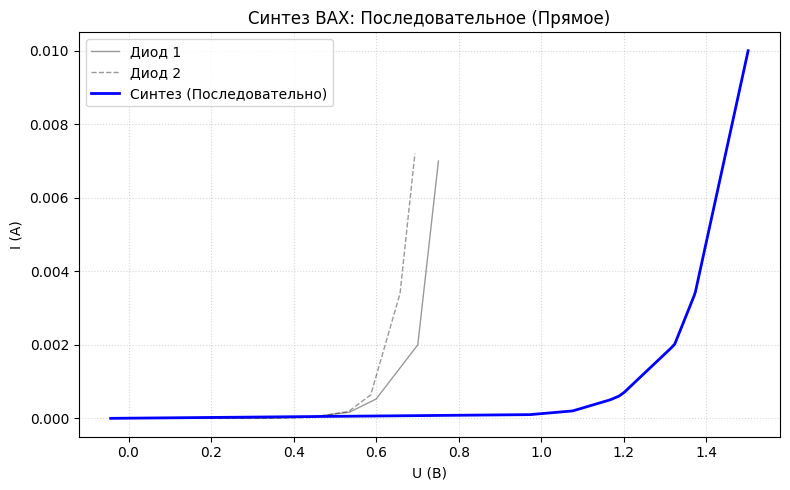

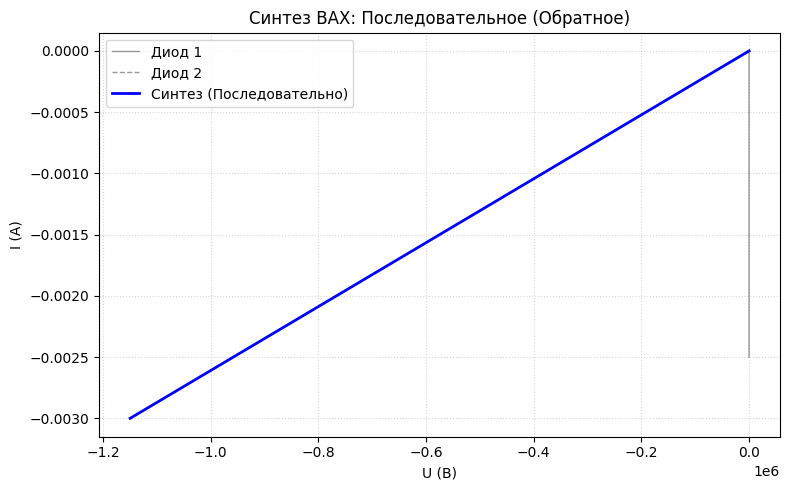

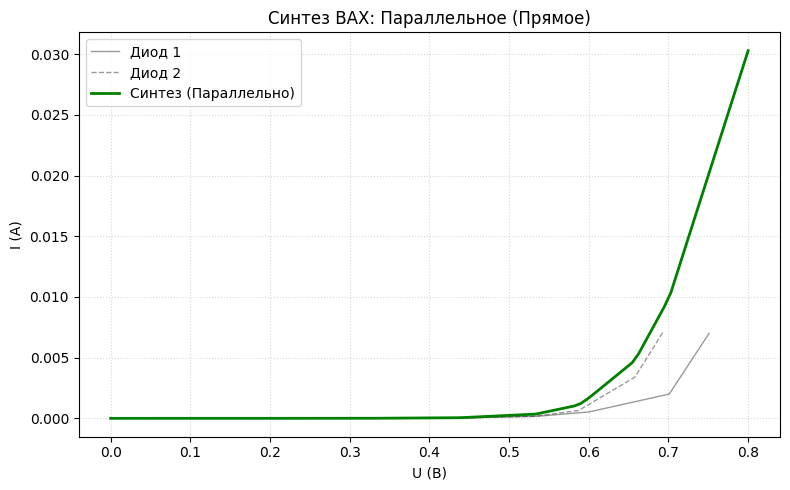

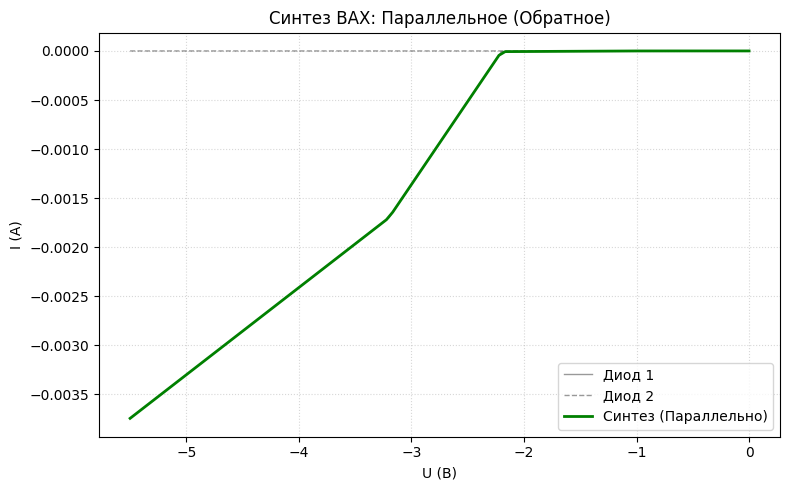

📈 Построение экспериментальных ВАХ (Часть 2)...


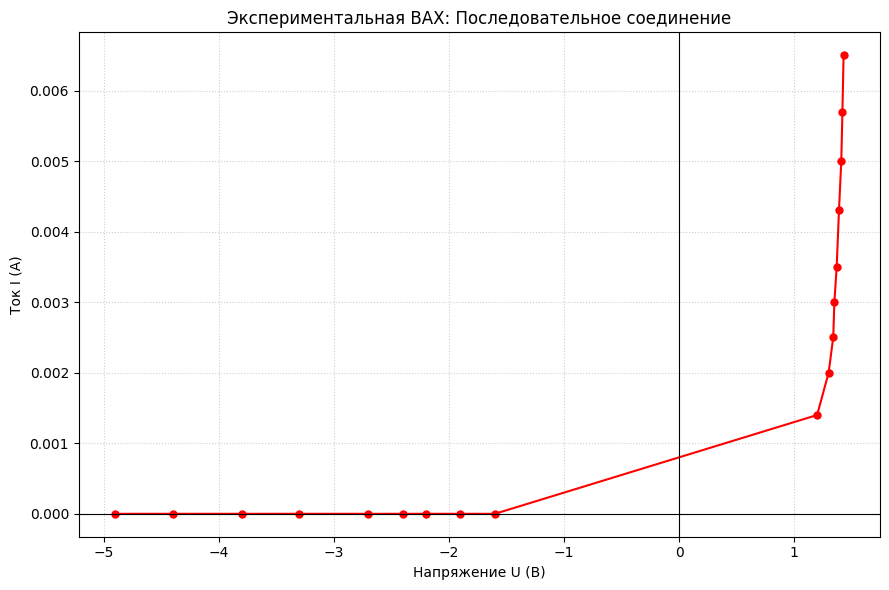

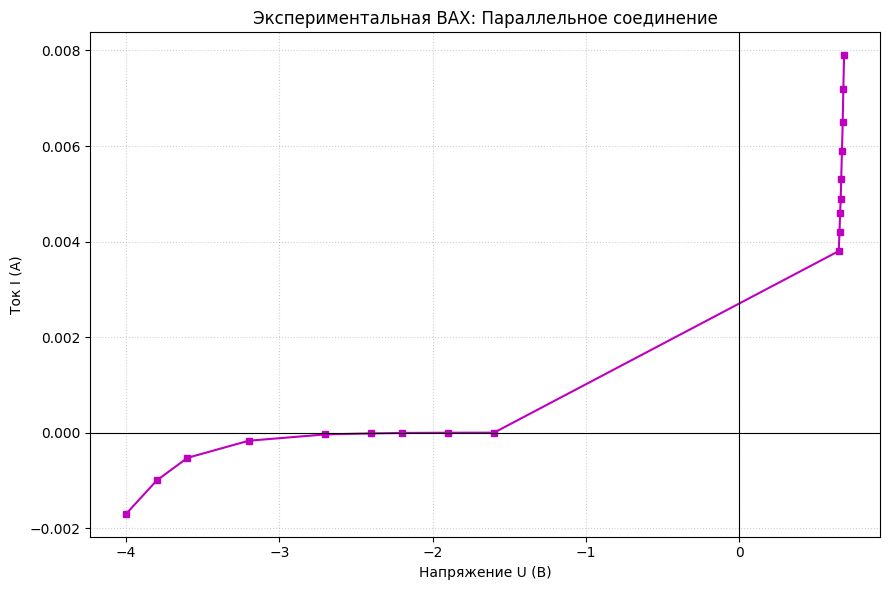

(None, None)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# ==========================================
# 1. ДАННЫЕ ИЗ ЧАСТИ 1 (Исходные диоды)
# ==========================================
d1_U = np.array([-4.1, -3.2, -2.2, -1.0, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.438, 0.535, 0.600, 0.701, 0.751])
d1_I = np.array([-2.5e-3, -1.7e-3, -7e-6, -260e-9, -48e-9, -24e-9, -17e-9, -12e-9, -9e-9, 
                 24e-9, 87e-9, 638e-9, 4e-6, 31e-6, 167e-6, 525e-6, 2e-3, 7e-3])

d2_U = np.array([-5.5, -3.2, -2.2, -1.1, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.439, 0.533, 0.587, 0.658, 0.694])
d2_I = np.array([-7e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, 
                 2e-9, 11e-9, 119e-9, 1.8e-6, 21e-6, 185e-6, 638e-6, 3.4e-3, 7.2e-3])

# ==========================================
# 2. ДАННЫЕ ИЗ ЧАСТИ 2 (Эксперимент)
# ==========================================
# Последовательное соединение
exp_ser_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.3, -3.8, -4.4, -4.9])
exp_ser_rev_I = np.array([-1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9])
exp_ser_fwd_U = np.array([1.2, 1.3, 1.34, 1.35, 1.37, 1.39, 1.41, 1.42, 1.43])
exp_ser_fwd_I = np.array([1.4e-3, 2.0e-3, 2.5e-3, 3.0e-3, 3.5e-3, 4.3e-3, 5.0e-3, 5.7e-3, 6.5e-3])

# Параллельное соединение
exp_par_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.2, -3.6, -3.8, -4.0])
exp_par_rev_I = np.array([-1.3e-6, -3.2e-6, -7.4e-6, -17e-6, -38e-6, -170e-6, -528e-6, -1e-3, -1.7e-3])
exp_par_fwd_U = np.array([0.649, 0.654, 0.658, 0.662, 0.665, 0.670, 0.675, 0.679, 0.684]) # 649mV -> 0.649V
exp_par_fwd_I = np.array([3.8e-3, 4.2e-3, 4.6e-3, 4.9e-3, 5.3e-3, 5.9e-3, 6.5e-3, 7.2e-3, 7.9e-3])

# ==========================================
# 3. РАСЧЕТ ГРАФИЧЕСКИМ МЕТОДОМ (Часть 1)
# ==========================================
def calc_graphic_series(I_range):
    f1 = interpolate.interp1d(d1_I, d1_U, kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_I, d2_U, kind='linear', fill_value="extrapolate")
    return f1(I_range) + f2(I_range), I_range

def calc_graphic_parallel(U_range):
    f1 = interpolate.interp1d(d1_U, d1_I, kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_U, d2_I, kind='linear', fill_value="extrapolate")
    return U_range, f1(U_range) + f2(U_range)

# ==========================================
# 4. ГРАФИКИ СИНТЕЗА (Без экспериментальных точек)
# ==========================================
print("📈 Построение графиков синтеза (Часть 1)...")

# 1. Последовательное Прямое
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_series(np.linspace(0, 0.01, 100))
plt.plot(Uc, Ic, 'b-', lw=2, label='Синтез (Последовательно)')
plt.title('Синтез ВАХ: Последовательное (Прямое)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 2. Последовательное Обратное
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_series(np.linspace(-0.003, 0, 100))
plt.plot(Uc, Ic, 'b-', lw=2, label='Синтез (Последовательно)')
plt.title('Синтез ВАХ: Последовательное (Обратное)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 3. Параллельное Прямое
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_parallel(np.linspace(0, 0.8, 100))
plt.plot(Uc, Ic, 'g-', lw=2, label='Синтез (Параллельно)')
plt.title('Синтез ВАХ: Параллельное (Прямое)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 4. Параллельное Обратное
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_parallel(np.linspace(-5.5, 0, 100))
plt.plot(Uc, Ic, 'g-', lw=2, label='Синтез (Параллельно)')
plt.title('Синтез ВАХ: Параллельное (Обратное)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()


# ==========================================
# 5. ГРАФИКИ ЭКСПЕРИМЕНТА (Часть 2)
# ==========================================
print("📈 Построение экспериментальных ВАХ (Часть 2)...")

# 5.1 Последовательное соединение (Полная ВАХ)
U_ser_all = np.concatenate((exp_ser_rev_U, exp_ser_fwd_U))
I_ser_all = np.concatenate((exp_ser_rev_I, exp_ser_fwd_I))
sort_idx = np.argsort(U_ser_all)

plt.figure(figsize=(9, 6))
plt.plot(U_ser_all[sort_idx], I_ser_all[sort_idx], 'r-o', linewidth=1.5, markersize=5)
plt.title('Экспериментальная ВАХ: Последовательное соединение')
plt.xlabel('Напряжение U (В)'), plt.ylabel('Ток I (А)')
plt.grid(True, ls=':', alpha=0.6)
plt.axhline(0, color='black', lw=0.8), plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(), plt.show()

# 5.2 Параллельное соединение (Полная ВАХ)
U_par_all = np.concatenate((exp_par_rev_U, exp_par_fwd_U))
I_par_all = np.concatenate((exp_par_rev_I, exp_par_fwd_I))
sort_idx = np.argsort(U_par_all)

plt.figure(figsize=(9, 6))
plt.plot(U_par_all[sort_idx], I_par_all[sort_idx], 'm-s', linewidth=1.5, markersize=5)
plt.title('Экспериментальная ВАХ: Параллельное соединение')
plt.xlabel('Напряжение U (В)'), plt.ylabel('Ток I (А)')
plt.grid(True, ls=':', alpha=0.6)
plt.axhline(0, color='black', lw=0.8), plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(), plt.show()

📈 Построение графиков синтеза (Часть 1)...


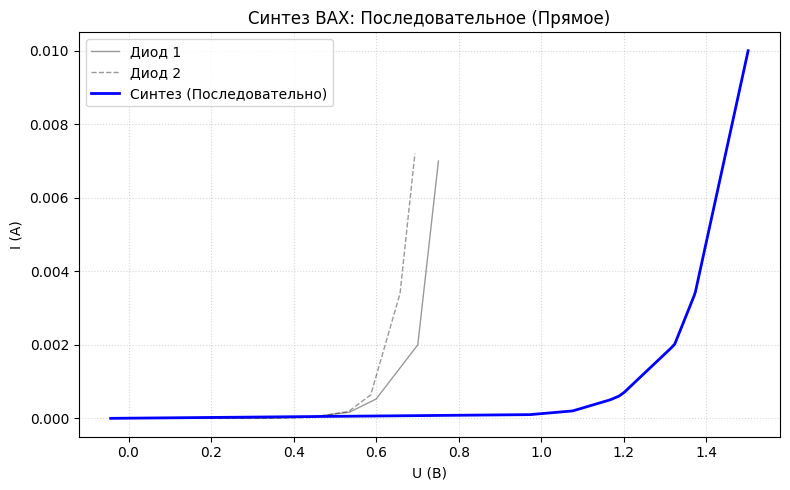

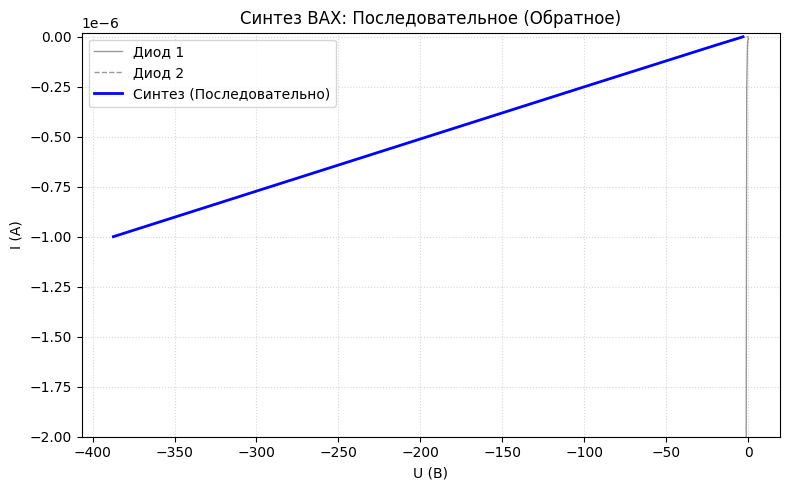

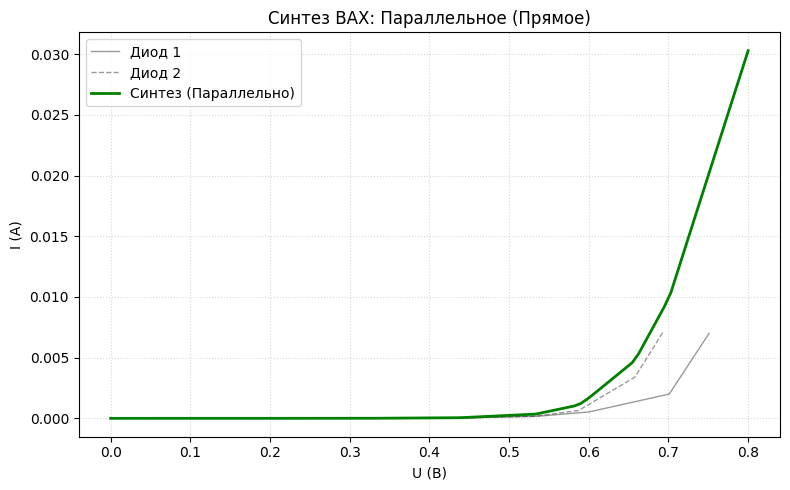

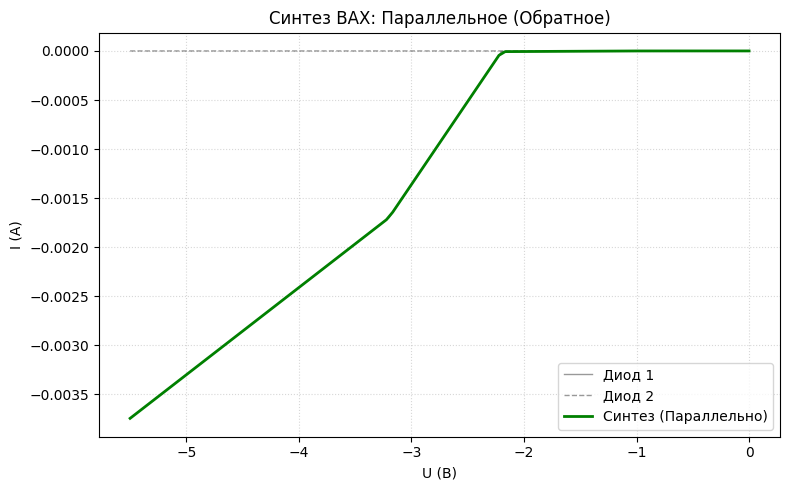

📈 Построение экспериментальных ВАХ (Часть 2)...


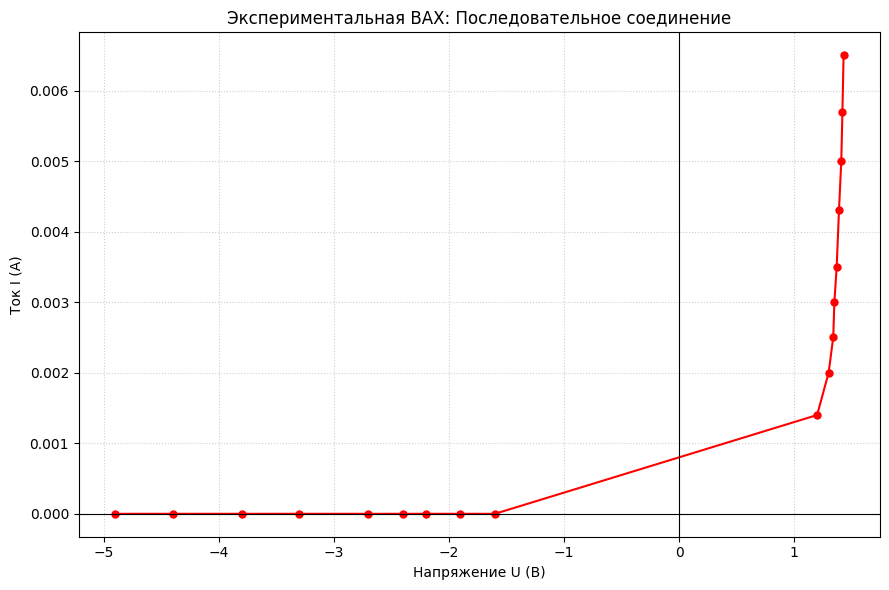

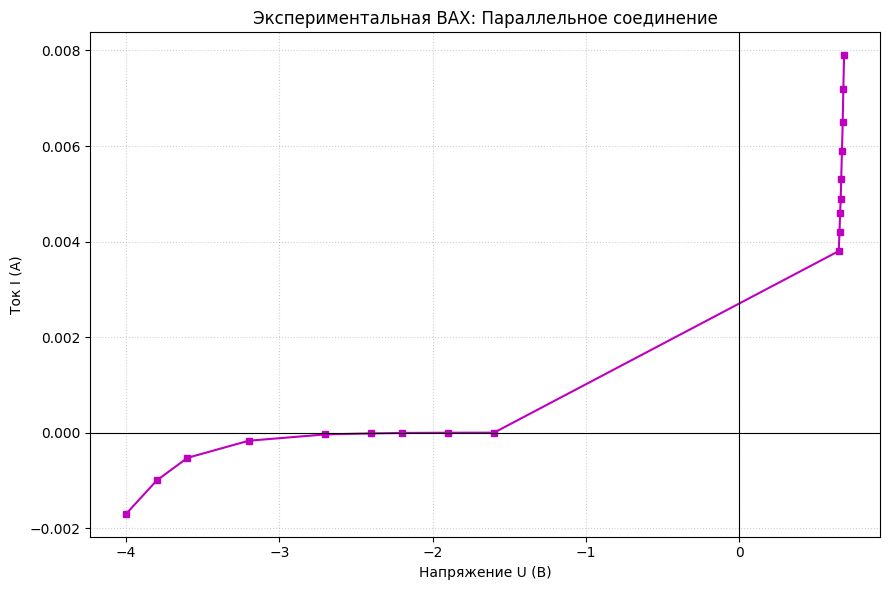

(None, None)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# ==========================================
# 1. ДАННЫЕ ИЗ ЧАСТИ 1 (Исходные диоды)
# ==========================================
d1_U = np.array([-4.1, -3.2, -2.2, -1.0, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.438, 0.535, 0.600, 0.701, 0.751])
d1_I = np.array([-2.5e-3, -1.7e-3, -7e-6, -260e-9, -48e-9, -24e-9, -17e-9, -12e-9, -9e-9, 
                 24e-9, 87e-9, 638e-9, 4e-6, 31e-6, 167e-6, 525e-6, 2e-3, 7e-3])

d2_U = np.array([-5.5, -3.2, -2.2, -1.1, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.439, 0.533, 0.587, 0.658, 0.694])
d2_I = np.array([-7e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, 
                 2e-9, 11e-9, 119e-9, 1.8e-6, 21e-6, 185e-6, 638e-6, 3.4e-3, 7.2e-3])

# ==========================================
# 2. ДАННЫЕ ИЗ ЧАСТИ 2 (Эксперимент)
# ==========================================
# Последовательное
exp_ser_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.3, -3.8, -4.4, -4.9])
exp_ser_rev_I = np.array([-1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9])
exp_ser_fwd_U = np.array([1.2, 1.3, 1.34, 1.35, 1.37, 1.39, 1.41, 1.42, 1.43])
exp_ser_fwd_I = np.array([1.4e-3, 2.0e-3, 2.5e-3, 3.0e-3, 3.5e-3, 4.3e-3, 5.0e-3, 5.7e-3, 6.5e-3])

# Параллельное
exp_par_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.2, -3.6, -3.8, -4.0])
exp_par_rev_I = np.array([-1.3e-6, -3.2e-6, -7.4e-6, -17e-6, -38e-6, -170e-6, -528e-6, -1e-3, -1.7e-3])
exp_par_fwd_U = np.array([0.649, 0.654, 0.658, 0.662, 0.665, 0.670, 0.675, 0.679, 0.684])
exp_par_fwd_I = np.array([3.8e-3, 4.2e-3, 4.6e-3, 4.9e-3, 5.3e-3, 5.9e-3, 6.5e-3, 7.2e-3, 7.9e-3])

# ==========================================
# 3. РАСЧЕТ ГРАФИЧЕСКИМ МЕТОДОМ
# ==========================================
def calc_graphic_series(I_range):
    # Сортируем данные для корректной интерполяции (по возрастанию тока)
    idx1 = np.argsort(d1_I); idx2 = np.argsort(d2_I)
    f1 = interpolate.interp1d(d1_I[idx1], d1_U[idx1], kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_I[idx2], d2_U[idx2], kind='linear', fill_value="extrapolate")
    return f1(I_range) + f2(I_range), I_range

def calc_graphic_parallel(U_range):
    idx1 = np.argsort(d1_U); idx2 = np.argsort(d2_U)
    f1 = interpolate.interp1d(d1_U[idx1], d1_I[idx1], kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_U[idx2], d2_I[idx2], kind='linear', fill_value="extrapolate")
    return U_range, f1(U_range) + f2(U_range)

# ==========================================
# 4. ГРАФИКИ СИНТЕЗА (Часть 1)
# ==========================================
print("📈 Построение графиков синтеза (Часть 1)...")

# 1. Последовательное Прямое
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_series(np.linspace(0, 0.01, 100))
plt.plot(Uc, Ic, 'b-', lw=2, label='Синтез (Последовательно)')
plt.title('Синтез ВАХ: Последовательное (Прямое)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 2. Последовательное Обратное (ИСПРАВЛЕННЫЙ МАСШТАБ)
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', lw=1, alpha=0.4, label='Диод 2')
# Используем диапазон токов утечки (мкА -> нА), а не мА
I_rev_range = np.linspace(-1e-6, -1e-9, 100) 
Uc, Ic = calc_graphic_series(I_rev_range)
plt.plot(Uc, Ic, 'b-', lw=2, label='Синтез (Последовательно)')
plt.title('Синтез ВАХ: Последовательное (Обратное)')
plt.xlabel('U (В)'), plt.ylabel('I (А)')
plt.grid(True, ls=':', alpha=0.5), plt.legend()
# Приближаем ось Y к области нано/микроампер, чтобы линия была видна
plt.ylim(-2e-6, 2e-8)
plt.tight_layout(), plt.show()

# 3. Параллельное Прямое
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_parallel(np.linspace(0, 0.8, 100))
plt.plot(Uc, Ic, 'g-', lw=2, label='Синтез (Параллельно)')
plt.title('Синтез ВАХ: Параллельное (Прямое)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 4. Параллельное Обратное
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_parallel(np.linspace(-5.5, 0, 100))
plt.plot(Uc, Ic, 'g-', lw=2, label='Синтез (Параллельно)')
plt.title('Синтез ВАХ: Параллельное (Обратное)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()


# ==========================================
# 5. ГРАФИКИ ЭКСПЕРИМЕНТА (Часть 2)
# ==========================================
print("📈 Построение экспериментальных ВАХ (Часть 2)...")

# 5.1 Последовательное соединение (Полная ВАХ)
U_ser_all = np.concatenate((exp_ser_rev_U, exp_ser_fwd_U))
I_ser_all = np.concatenate((exp_ser_rev_I, exp_ser_fwd_I))
sort_idx = np.argsort(U_ser_all)

plt.figure(figsize=(9, 6))
plt.plot(U_ser_all[sort_idx], I_ser_all[sort_idx], 'r-o', linewidth=1.5, markersize=5)
plt.title('Экспериментальная ВАХ: Последовательное соединение')
plt.xlabel('Напряжение U (В)'), plt.ylabel('Ток I (А)')
plt.grid(True, ls=':', alpha=0.6)
plt.axhline(0, color='black', lw=0.8), plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(), plt.show()

# 5.2 Параллельное соединение (Полная ВАХ)
U_par_all = np.concatenate((exp_par_rev_U, exp_par_fwd_U))
I_par_all = np.concatenate((exp_par_rev_I, exp_par_fwd_I))
sort_idx = np.argsort(U_par_all)

plt.figure(figsize=(9, 6))
plt.plot(U_par_all[sort_idx], I_par_all[sort_idx], 'm-s', linewidth=1.5, markersize=5)
plt.title('Экспериментальная ВАХ: Параллельное соединение')
plt.xlabel('Напряжение U (В)'), plt.ylabel('Ток I (А)')
plt.grid(True, ls=':', alpha=0.6)
plt.axhline(0, color='black', lw=0.8), plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(), plt.show()

📈 Построение графиков синтеза (Часть 1)...


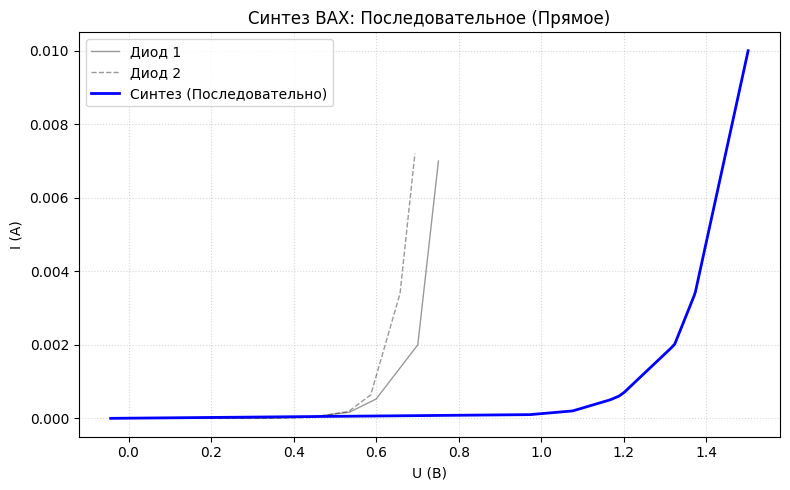

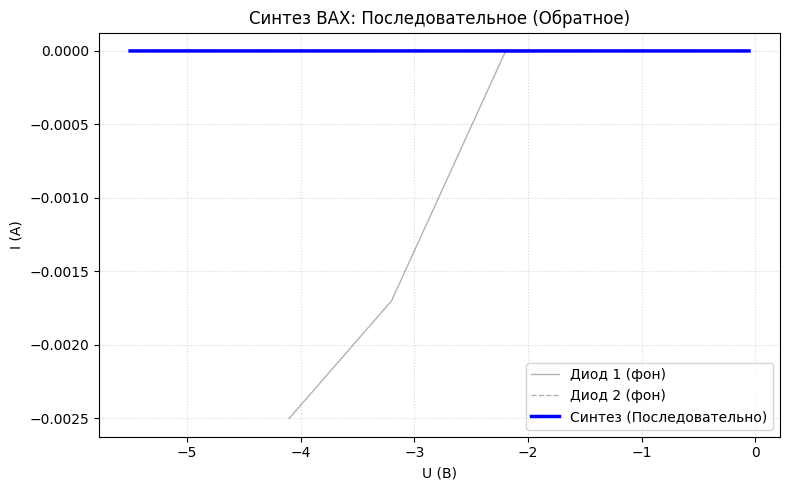

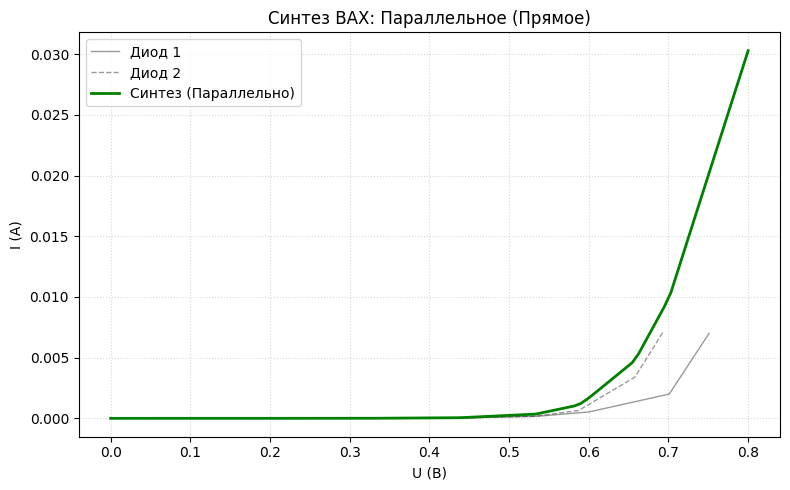

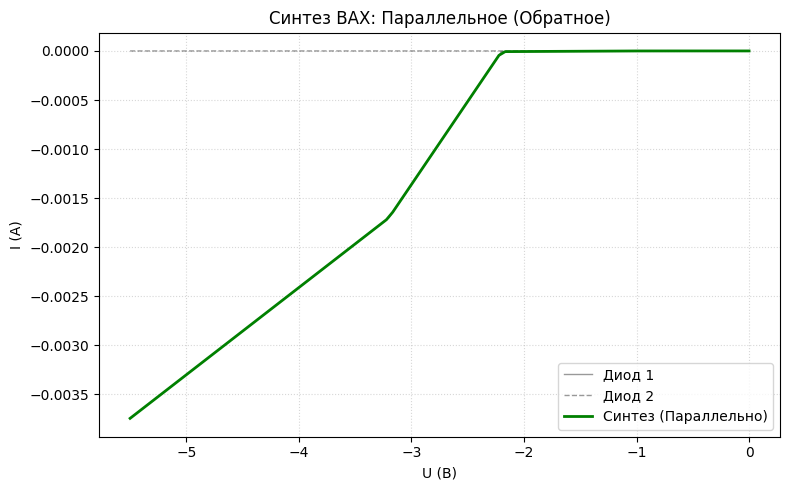

📈 Построение экспериментальных ВАХ (Часть 2)...


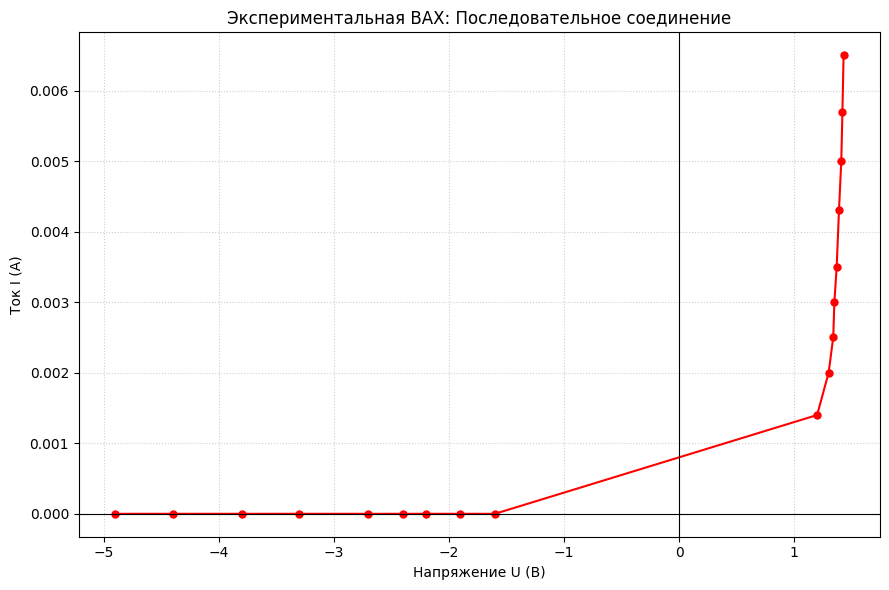

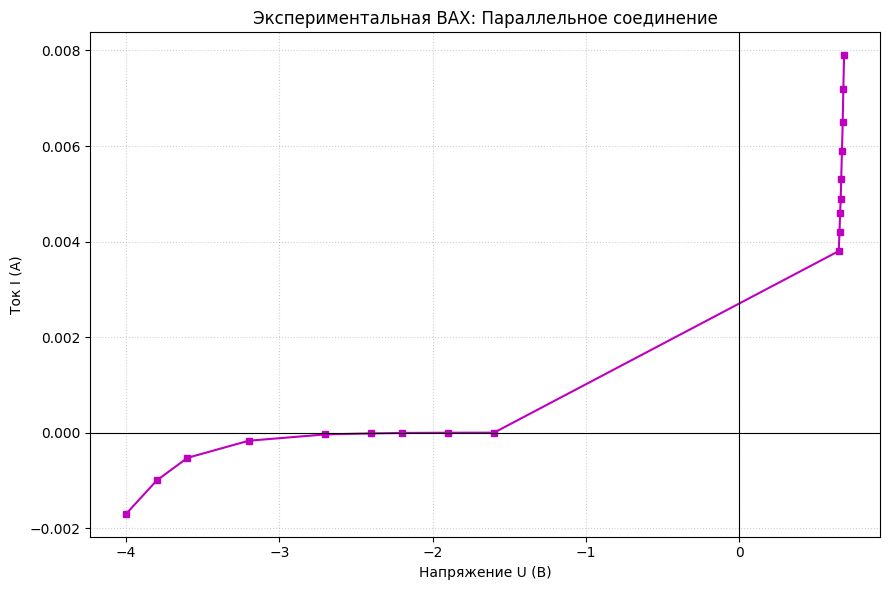

(None, None)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# ==========================================
# 1. ДАННЫЕ ИЗ ЧАСТИ 1 (Исходные диоды)
# ==========================================
d1_U = np.array([-4.1, -3.2, -2.2, -1.0, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.438, 0.535, 0.600, 0.701, 0.751])
d1_I = np.array([-2.5e-3, -1.7e-3, -7e-6, -260e-9, -48e-9, -24e-9, -17e-9, -12e-9, -9e-9, 
                 24e-9, 87e-9, 638e-9, 4e-6, 31e-6, 167e-6, 525e-6, 2e-3, 7e-3])

d2_U = np.array([-5.5, -3.2, -2.2, -1.1, -0.551, -0.330, -0.220, -0.110, -0.055, 
                 0.055, 0.110, 0.220, 0.330, 0.439, 0.533, 0.587, 0.658, 0.694])
d2_I = np.array([-7e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, 
                 2e-9, 11e-9, 119e-9, 1.8e-6, 21e-6, 185e-6, 638e-6, 3.4e-3, 7.2e-3])

# ==========================================
# 2. ДАННЫЕ ИЗ ЧАСТИ 2 (Эксперимент)
# ==========================================
# Последовательное
exp_ser_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.3, -3.8, -4.4, -4.9])
exp_ser_rev_I = np.array([-1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9, -1e-9])
exp_ser_fwd_U = np.array([1.2, 1.3, 1.34, 1.35, 1.37, 1.39, 1.41, 1.42, 1.43])
exp_ser_fwd_I = np.array([1.4e-3, 2.0e-3, 2.5e-3, 3.0e-3, 3.5e-3, 4.3e-3, 5.0e-3, 5.7e-3, 6.5e-3])

# Параллельное
exp_par_rev_U = np.array([-1.6, -1.9, -2.2, -2.4, -2.7, -3.2, -3.6, -3.8, -4.0])
exp_par_rev_I = np.array([-1.3e-6, -3.2e-6, -7.4e-6, -17e-6, -38e-6, -170e-6, -528e-6, -1e-3, -1.7e-3])
exp_par_fwd_U = np.array([0.649, 0.654, 0.658, 0.662, 0.665, 0.670, 0.675, 0.679, 0.684])
exp_par_fwd_I = np.array([3.8e-3, 4.2e-3, 4.6e-3, 4.9e-3, 5.3e-3, 5.9e-3, 6.5e-3, 7.2e-3, 7.9e-3])

# ==========================================
# 3. РАСЧЕТ ГРАФИЧЕСКИМ МЕТОДОМ
# ==========================================
def calc_graphic_series(I_range):
    idx1 = np.argsort(d1_I); idx2 = np.argsort(d2_I)
    f1 = interpolate.interp1d(d1_I[idx1], d1_U[idx1], kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_I[idx2], d2_U[idx2], kind='linear', fill_value="extrapolate")
    return f1(I_range) + f2(I_range), I_range

def calc_graphic_parallel(U_range):
    idx1 = np.argsort(d1_U); idx2 = np.argsort(d2_U)
    f1 = interpolate.interp1d(d1_U[idx1], d1_I[idx1], kind='linear', fill_value="extrapolate")
    f2 = interpolate.interp1d(d2_U[idx2], d2_I[idx2], kind='linear', fill_value="extrapolate")
    return U_range, f1(U_range) + f2(U_range)

# ==========================================
# 4. ГРАФИКИ СИНТЕЗА (Часть 1)
# ==========================================
print("📈 Построение графиков синтеза (Часть 1)...")

# 1. Последовательное Прямое
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_series(np.linspace(0, 0.01, 100))
plt.plot(Uc, Ic, 'b-', lw=2, label='Синтез (Последовательно)')
plt.title('Синтез ВАХ: Последовательное (Прямое)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 2. Последовательное Обратное (копия ВАХ выпрямителя)
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', lw=1, alpha=0.3, label='Диод 1 (фон)')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', lw=1, alpha=0.3, label='Диод 2 (фон)')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'b-', lw=2.5, label='Синтез (Последовательно)')
plt.title('Синтез ВАХ: Последовательное (Обратное)')
plt.xlabel('U (В)'), plt.ylabel('I (А)')
plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 3. Параллельное Прямое
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U>0], d1_I[d1_U>0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U>0], d2_I[d2_U>0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_parallel(np.linspace(0, 0.8, 100))
plt.plot(Uc, Ic, 'g-', lw=2, label='Синтез (Параллельно)')
plt.title('Синтез ВАХ: Параллельное (Прямое)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()

# 4. Параллельное Обратное
plt.figure(figsize=(8, 5))
plt.plot(d1_U[d1_U<0], d1_I[d1_U<0], 'k-', lw=1, alpha=0.4, label='Диод 1')
plt.plot(d2_U[d2_U<0], d2_I[d2_U<0], 'k--', lw=1, alpha=0.4, label='Диод 2')
Uc, Ic = calc_graphic_parallel(np.linspace(-5.5, 0, 100))
plt.plot(Uc, Ic, 'g-', lw=2, label='Синтез (Параллельно)')
plt.title('Синтез ВАХ: Параллельное (Обратное)')
plt.xlabel('U (В)'), plt.ylabel('I (А)'), plt.grid(True, ls=':', alpha=0.5), plt.legend()
plt.tight_layout(), plt.show()


# ==========================================
# 5. ГРАФИКИ ЭКСПЕРИМЕНТА (Часть 2)
# ==========================================
print("📈 Построение экспериментальных ВАХ (Часть 2)...")

# 5.1 Последовательное соединение (Полная ВАХ)
U_ser_all = np.concatenate((exp_ser_rev_U, exp_ser_fwd_U))
I_ser_all = np.concatenate((exp_ser_rev_I, exp_ser_fwd_I))
sort_idx = np.argsort(U_ser_all)

plt.figure(figsize=(9, 6))
plt.plot(U_ser_all[sort_idx], I_ser_all[sort_idx], 'r-o', linewidth=1.5, markersize=5)
plt.title('Экспериментальная ВАХ: Последовательное соединение')
plt.xlabel('Напряжение U (В)'), plt.ylabel('Ток I (А)')
plt.grid(True, ls=':', alpha=0.6)
plt.axhline(0, color='black', lw=0.8), plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(), plt.show()

# 5.2 Параллельное соединение (Полная ВАХ)
U_par_all = np.concatenate((exp_par_rev_U, exp_par_fwd_U))
I_par_all = np.concatenate((exp_par_rev_I, exp_par_fwd_I))
sort_idx = np.argsort(U_par_all)

plt.figure(figsize=(9, 6))
plt.plot(U_par_all[sort_idx], I_par_all[sort_idx], 'm-s', linewidth=1.5, markersize=5)
plt.title('Экспериментальная ВАХ: Параллельное соединение')
plt.xlabel('Напряжение U (В)'), plt.ylabel('Ток I (А)')
plt.grid(True, ls=':', alpha=0.6)
plt.axhline(0, color='black', lw=0.8), plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(), plt.show()